In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
file = 'Scenario_Analysis.xlsx'
df = pd.read_excel(file, sheet_name='CO2Storage')
df = df.set_index(df.columns[0])
df = df.T
hours = df.index.str.replace("T","").astype(int)
start_date = pd.Timestamp("2019-01-01 00:00")
dt_index = start_date + pd.to_timedelta(hours-1, unit="h")
df.index = dt_index
df.index.name = "datetime"
df.index.freq = 'h'

#representative week
week = df.loc["2019-02-10":"2019-02-17"]



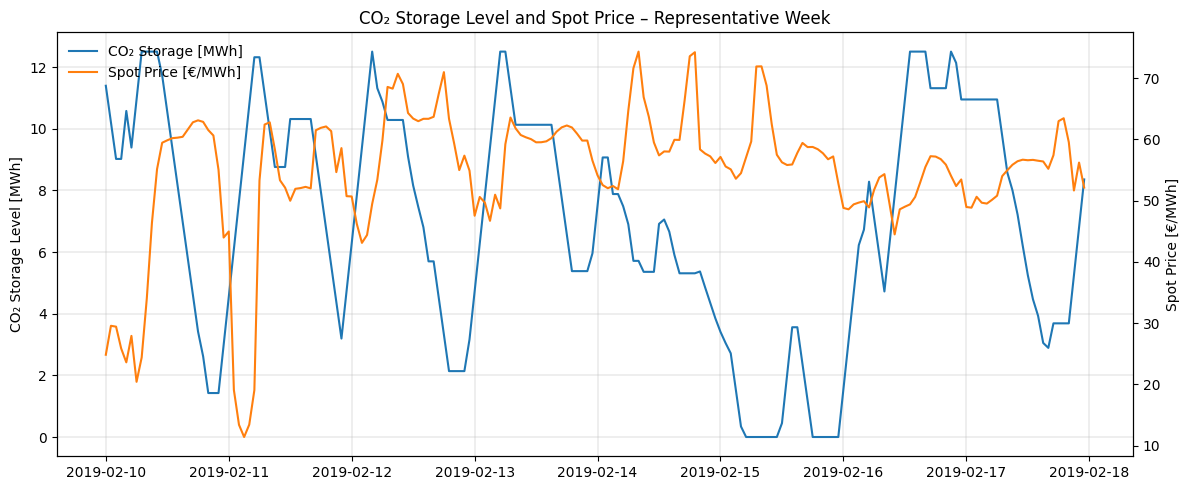

In [4]:
# PLOT SAME FIGURE W/ SECONDARY AXIS
fig, ax1 = plt.subplots(figsize=(12, 5))

# --- Storage (primary y-axis) ---
storage_line = ax1.plot(
    week.index,
    week["Baseline"],
    color="tab:blue",
    linewidth=1.5,
    label="CO₂ Storage [MWh]"
)
ax1.set_ylabel("CO₂ Storage Level [MWh]")
ax1.grid(True, linewidth=0.3)

# --- Secondary y-axis for Spot Price ---
ax2 = ax1.twinx()
price_line = ax2.plot(
    week.index,
    week["SpotPrice"],
    color="tab:orange",
    linewidth=1.5,
    label="Spot Price [€/MWh]"
)
ax2.set_ylabel("Spot Price [€/MWh]")

# --- Combined legend ---
lines = storage_line + price_line
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=False)

# --- Title and layout ---
plt.title("CO₂ Storage Level and Spot Price – Representative Week")
plt.tight_layout()
plt.show()

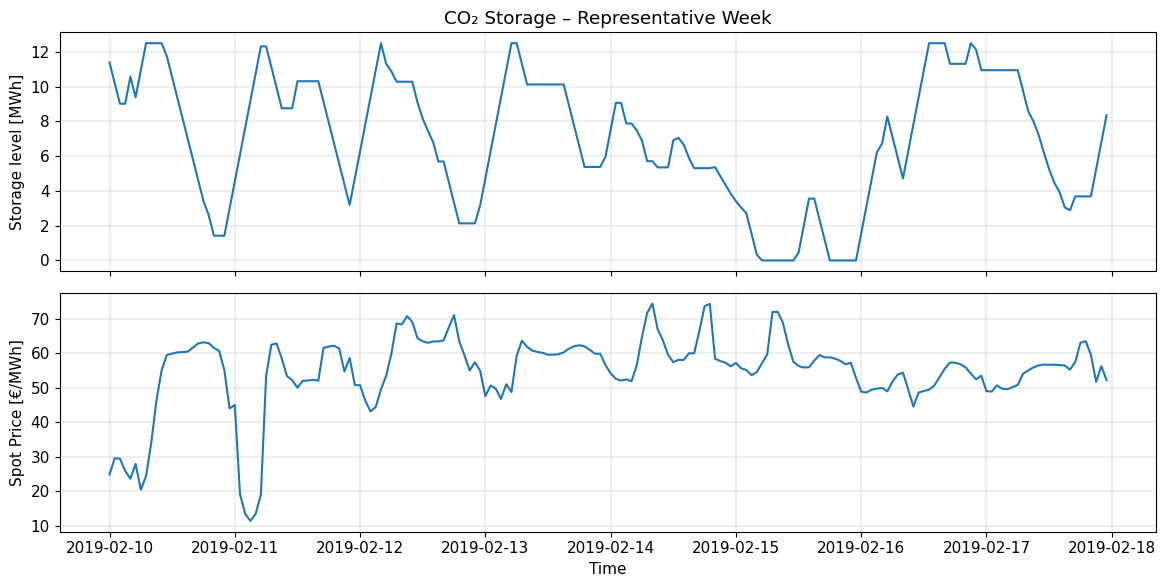

In [8]:
# PLOT W/ SUBFIGURES

# Select which scenario to plot
storage = week["Baseline"]
price   = week["SpotPrice"]

# ---- Plot using your preferred subplot style ----
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})
fig, axes = plt.subplots(2, 1, sharex=True)

# Panel 1 — Storage level
axes[0].plot(storage.index, storage.values, linewidth=1.5)
axes[0].set_ylabel("Storage level [MWh]")
axes[0].set_title("CO₂ Storage – Representative Week")
axes[0].grid(True, linewidth=0.3)

# Panel 2 — Spot price
axes[1].plot(price.index, price.values, linewidth=1.5)
axes[1].set_ylabel("Spot Price [€/MWh]")
axes[1].set_xlabel("Time")
axes[1].grid(True, linewidth=0.3)

fig.tight_layout()
plt.show()

<Axes: xlabel='datetime'>

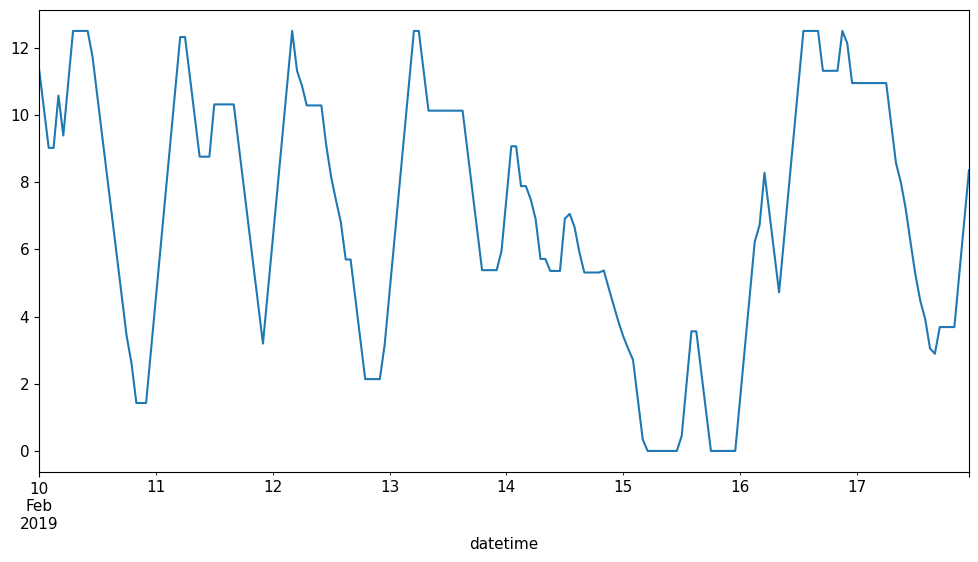

In [11]:
week['Baseline'].plot()